In [2]:
import io
from base64 import b64encode
import fitz  # PyMuPDF

def extract_pdf_pages_base64(pdf_file, dpi=300, fmt="png"):
    """Extracts each page of the PDF as a dict with base64 representation."""
    zoom = dpi / 72.0
    mat = fitz.Matrix(zoom, zoom)
    
    doc = fitz.open(pdf_file)
    pages_result = []
    
    for i, page in enumerate(doc, start=1):
        pix = page.get_pixmap(matrix=mat, alpha=False)
        img_bytes = pix.pil_tobytes(format=fmt.upper())
        base64_str = b64encode(img_bytes).decode("utf-8")
        
        pages_result.append({
            "page_number": i,
            "base64_str": base64_str,
        })
    
    doc.close()
    return pages_result

# Load single PDF
pages = extract_pdf_pages_base64("../data/PDFs/1.pdf")

In [11]:
from base64 import b64decode, b64encode
import matplotlib.pyplot as plt

byte_lengths = [len(b64decode(page['base64_str'])) for page in pages]
print(max(byte_lengths))
print(min(byte_lengths))
print(sum(byte_lengths)/len(byte_lengths))

1303055
1047632
1167010.4


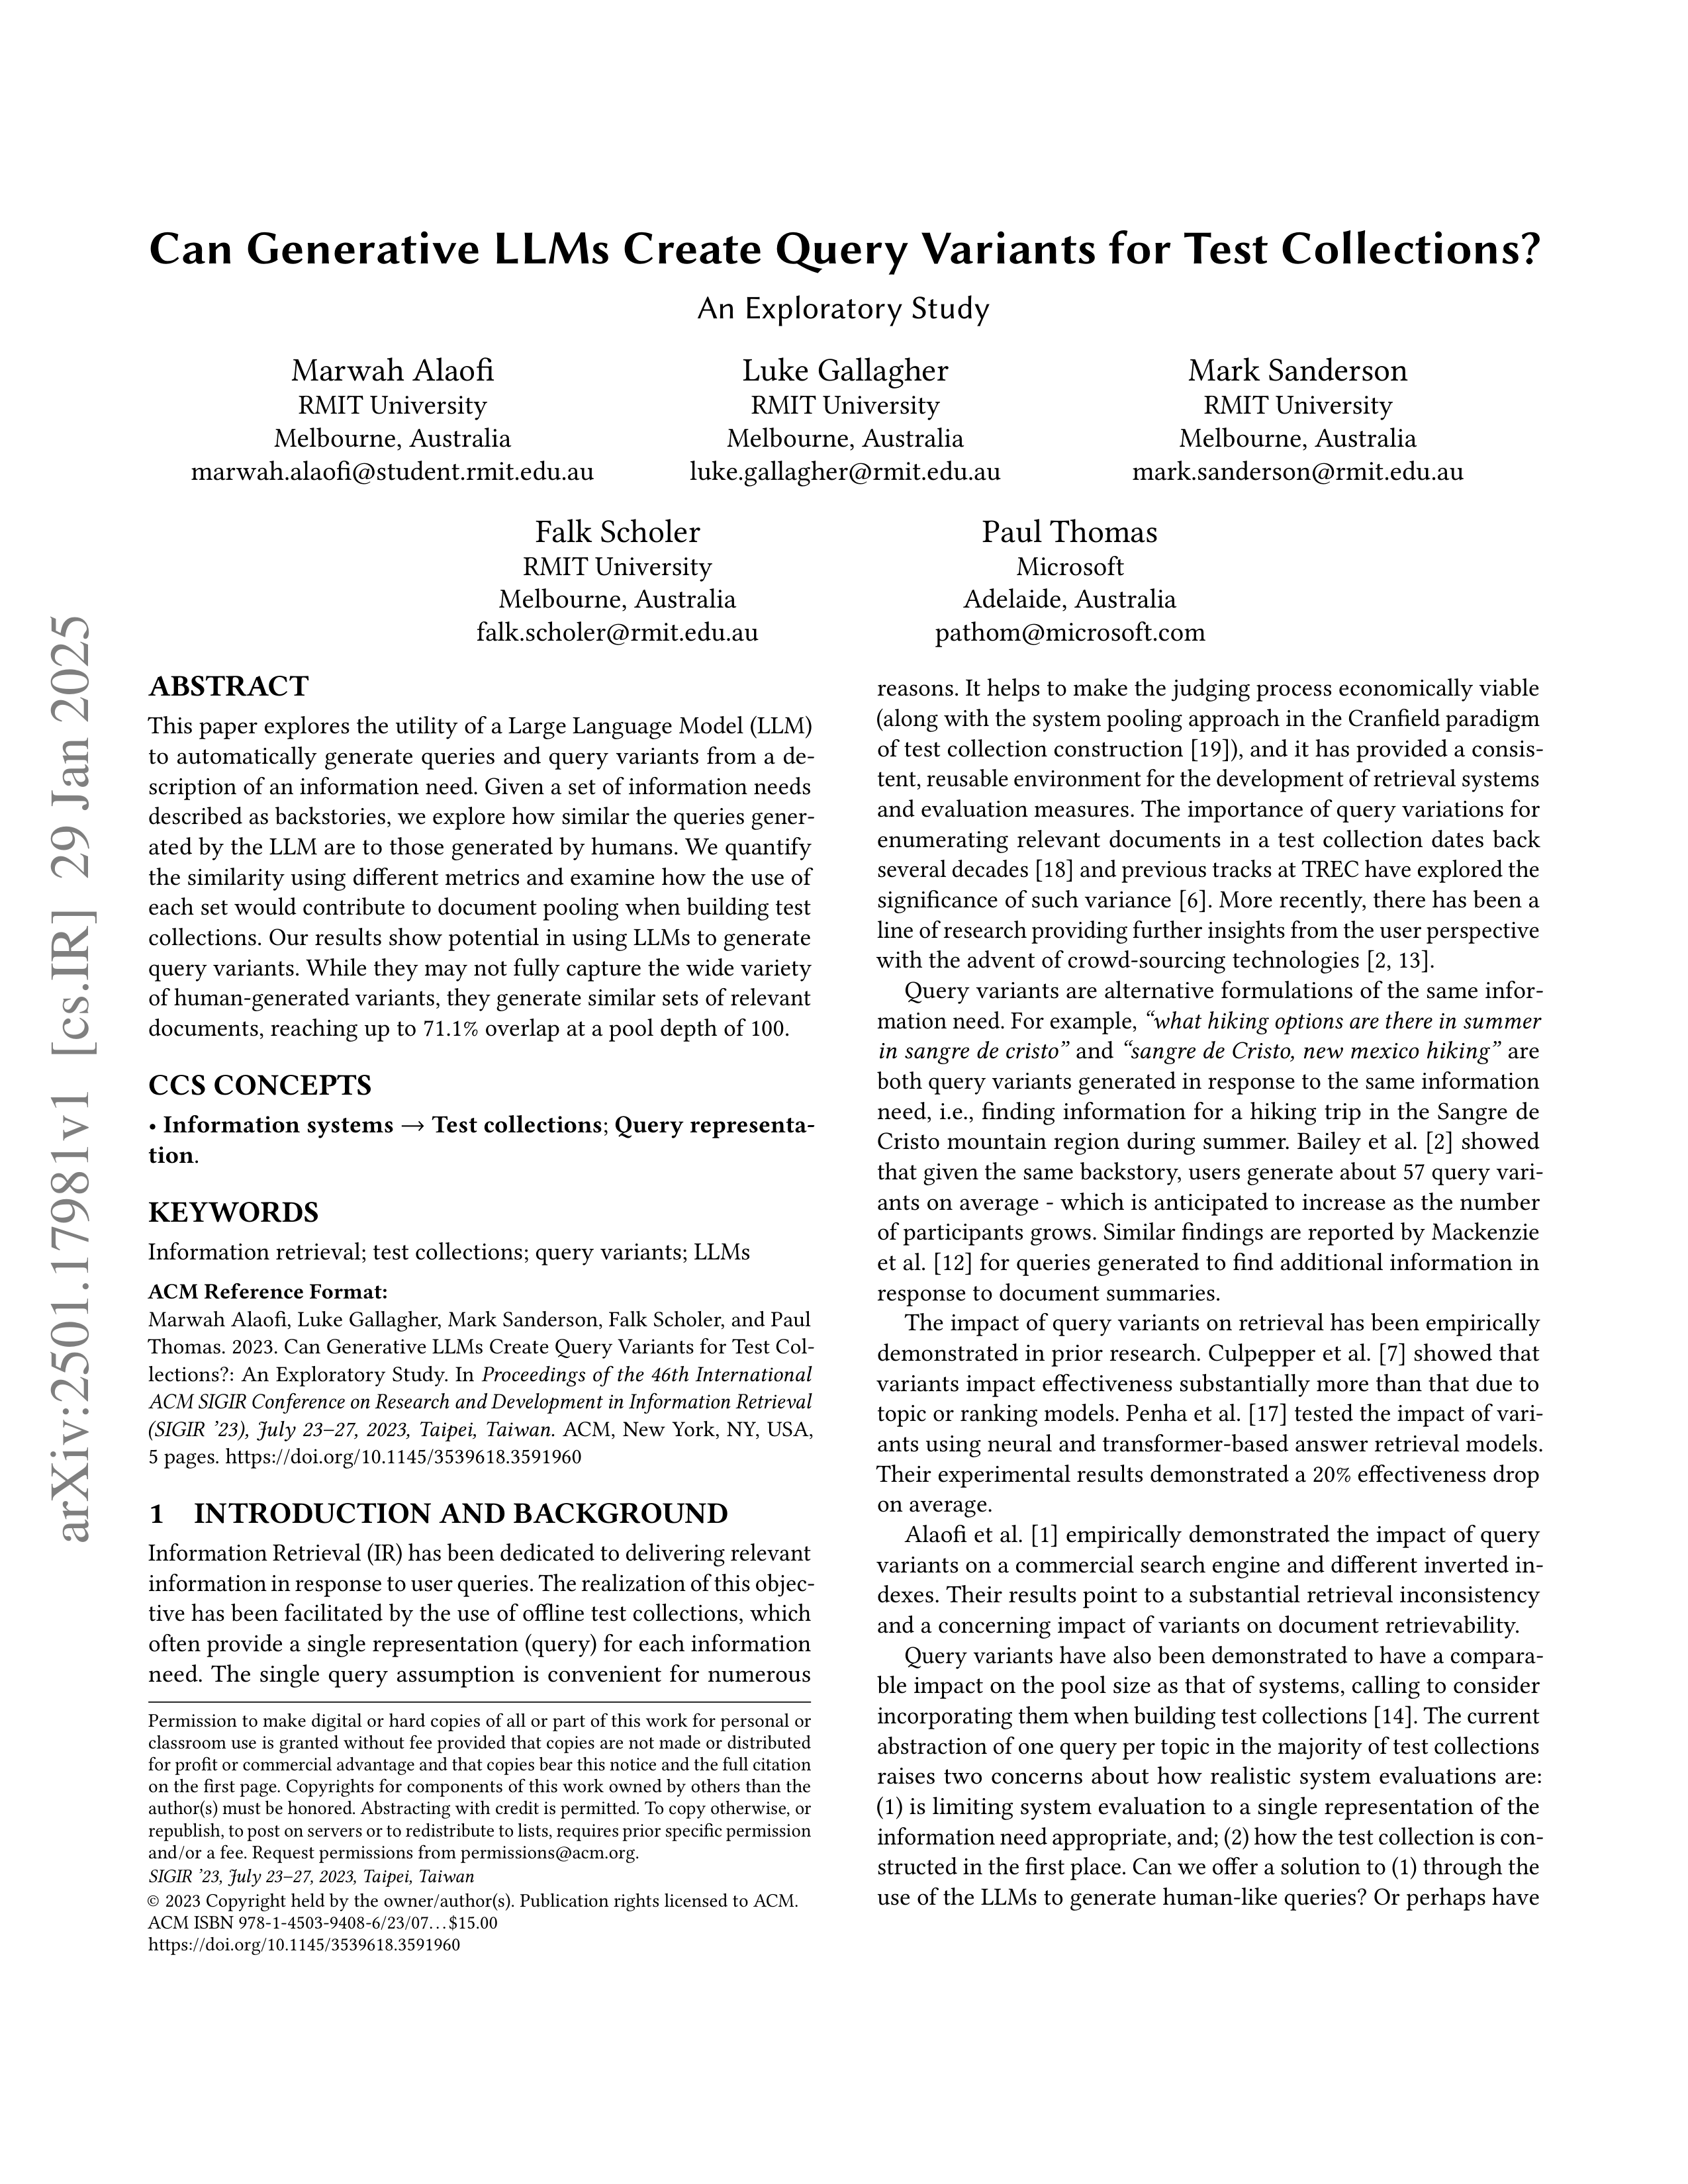

In [12]:
from IPython.display import display, Image

display(Image(data=b64decode(pages[0]["base64_str"])))